In [ ]:
from pathlib import Path
from scipy.io import loadmat
import scipy.signal as sgn
import pandas as pd
import numpy as np
import re
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


In [ ]:
from Functions import remove_baseline_filter,  preprocess_one_file , stem_to_subject_id , prepare_split_data_loaders,training_curve_plot , WindowDataset, CNN1D, train_model_with_loaders, eval_loader_binary , run_one_experiment , select_channels

ImportError: cannot import name 'run_one_experiment' from 'Functions' (c:\Users\saber\thesis_second_try\Github_repo\Modeling_Breathing_Signals-\study1\Functions.py)

## Preprocessing step

In [ ]:

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")


# Parameters
FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap
batch_size = 64

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# ────────────────────────────────────────────────
# The baseline function 
SOS = remove_baseline_filter(FS_IN)

#────────────────────────────────────────────────
# Run over alla the files
mat_files = sorted(folder.glob("*.mat"))
participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]
print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

#────────────────────────────────────────────────
# Split the files in mouth and nose 
nose_files, mouth_files, skipped = [], [], []
for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue
    pid = int(m.group(1))
    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

#────────────────────────────────────────────────
# Preprocess each group 
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []
# 1. for nose 
for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "nose", str(e)))
# 2. for mouth
for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

#────────────────────────────────────────────────
# Stacking the tensors 
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 4, 2048)
X_mouth shape: (103, 9, 4, 2048)


In [ ]:
# Checking that everything is working
mouth_keys = sorted(mouth_tensors_by_participant.keys()) 
# print(mouth_keys)
print("X_nose shape:", X_mouth .shape)
X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
print("First 5 keys:", mouth_keys[:5])

X_nose shape: (103, 9, 4, 2048)
First 5 keys: ['resting_state_participant_201', 'resting_state_participant_210', 'resting_state_participant_211', 'resting_state_participant_212', 'resting_state_participant_213']


## Dataframe for the mouth 
The df was previously save cleaned and saved locally 

In [ ]:
import pandas as pd
Path_subject = r"df_mouth.csv"
df_mouth= pd.read_csv(Path_subject)
df_mouth.head()

,Subject Number,Gender,Age
0,1,1,27
1,10,1,37
2,11,1,29
3,12,0,25
4,13,0,31


In [ ]:
gender_by_subject = dict(zip(df_mouth["Subject Number"], df_mouth["Gender"]))
gender_by_subject # this is subject id and their correct gender 


{1: 1,
 10: 1,
 11: 1,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 1,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 1,
 29: 1,
 30: 1,
 31: 0,
 32: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 1,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 1,
 49: 0,
 50: 1,
 51: 0,
 52: 0,
 53: 1,
 54: 1,
 56: 0,
 57: 1,
 58: 0,
 59: 1,
 60: 0,
 61: 0,
 62: 0,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 1,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 0,
 76: 0,
 77: 1,
 78: 0,
 79: 0,
 80: 0,
 81: 0,
 82: 0,
 83: 0,
 84: 0,
 85: 1,
 86: 1,
 87: 1,
 88: 0,
 89: 0,
 90: 0,
 91: 1,
 92: 0,
 93: 1,
 94: 0,
 95: 1,
 96: 0,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 1,
 102: 0,
 103: 1,
 104: 0,
 105: 1,
 106: 0,
 107: 0,
 108: 1,
 109: 1,
 110: 0,
 111: 0,
 112: 1}

In [ ]:
mouth_ids_from_files = np.array([stem_to_subject_id(k) for k in mouth_keys], dtype=int)

print("First 10 subject IDs from files:", mouth_ids_from_files[:10])
print("Number of participants from files:", len(mouth_ids_from_files))
print("Unique IDs:", len(np.unique(mouth_ids_from_files)))


mouth_ids_for_labels = mouth_ids_from_files - 200

print("First 10 raw mouth IDs:   ", mouth_ids_from_files[:10])
print("First 10 mapped label IDs:", mouth_ids_for_labels[:10])

y_mouth = np.array([gender_by_subject[sid] for sid in mouth_ids_for_labels], dtype=int)
print("y_nose gender:", y_mouth)
print("y_nose shape:", y_mouth.shape)
print("Gender counts [0,1]:", np.bincount(y_mouth))


First 10 subject IDs from files: [201 210 211 212 213 214 215 216 217 218]
Number of participants from files: 103
Unique IDs: 103
First 10 raw mouth IDs:    [201 210 211 212 213 214 215 216 217 218]
First 10 mapped label IDs: [ 1 10 11 12 13 14 15 16 17 18]
y_nose gender: [1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1]
y_nose shape: (103,)
Gender counts [0,1]: [65 38]


# The split 

In [ ]:


train_loader, val_loader, test_loader, meta = prepare_split_data_loaders(
    X_mouth, y_mouth,
    seed=6,
    batch_size=batch_size,
    normalize=True,
    return_meta=True
)

# baseline: majority-class accuracy on validation participants
X_val_p = meta["X_val_p"]
y_val_p = meta["y_val_p"]
baseline_acc = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))
# ────────────────────────────────────────────────
#  Quick sanity checks on test set 

print("\nFirst 20 test window labels:", meta['y_test'][10:40])

print("Example test window [0] – channel means:", meta['X_test'][0].mean(axis=1))

# If you want to see beginning of first channel of first test window:
print("Example test window[0] channel 0 – first 30 values:")
print(meta['X_test'][0, 0, :30])

X_mouth:     (103, 9, 4, 2048)
y_mouth:     (103,)   unique: [0 1]   counts: [65 38]

After normalization (train mean per ch): [-4.7959134e-09  6.7182587e-10 -1.6819527e-09  8.4376234e-10]
After normalization (train std  per ch): [1.         0.9999992  0.9999996  0.99999964]

Window-level shapes:
X_train:     (585, 4, 2048)  y_train: (585,)  counts: [369 216]
X_val  :     (153, 4, 2048)  y_val  : (153,)  counts: [99 54]
X_test :     (189, 4, 2048)  y_test : (189,)  counts: [117  72]

First 20 test window labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0]
Example test window [0] – channel means: [ 0.00054022 -0.00026018 -0.00040301  0.0008239 ]
Example test window[0] channel 0 – first 30 values:
[-1.0501543e-01 -4.5349255e-01 -4.2773762e-01 -8.5186404e-01
  2.0505893e+00  9.2298098e+00  4.9646468e+00 -5.9669185e-01
 -9.1158813e-01 -1.3486962e+00 -1.1989032e+00 -1.2329762e+00
 -1.0165839e+00 -9.0935355e-01 -8.4389001e-01 -8.6067557e-01
 -8.6207855e-01 -8.6781174e-01 -9

## Training step 

Epoch 01 | train loss 0.8769 acc 0.629 | val loss 0.8505 acc 0.627
Epoch 02 | train loss 0.8354 acc 0.656 | val loss 0.8327 acc 0.608
Epoch 03 | train loss 0.8312 acc 0.656 | val loss 0.8184 acc 0.667
Epoch 04 | train loss 0.8312 acc 0.667 | val loss 0.8101 acc 0.680
Epoch 05 | train loss 0.8305 acc 0.665 | val loss 0.8018 acc 0.706
Epoch 06 | train loss 0.8151 acc 0.672 | val loss 0.7998 acc 0.667
Epoch 07 | train loss 0.7903 acc 0.691 | val loss 0.7964 acc 0.686
Epoch 08 | train loss 0.7936 acc 0.687 | val loss 0.7906 acc 0.706
Epoch 09 | train loss 0.7858 acc 0.680 | val loss 0.7871 acc 0.706
Epoch 10 | train loss 0.7714 acc 0.684 | val loss 0.7850 acc 0.693
Epoch 11 | train loss 0.7785 acc 0.672 | val loss 0.7873 acc 0.680
Epoch 12 | train loss 0.7774 acc 0.694 | val loss 0.7855 acc 0.673
Epoch 13 | train loss 0.7487 acc 0.737 | val loss 0.7737 acc 0.673
Epoch 14 | train loss 0.7488 acc 0.730 | val loss 0.7692 acc 0.673
Epoch 15 | train loss 0.7439 acc 0.733 | val loss 0.7696 acc 0

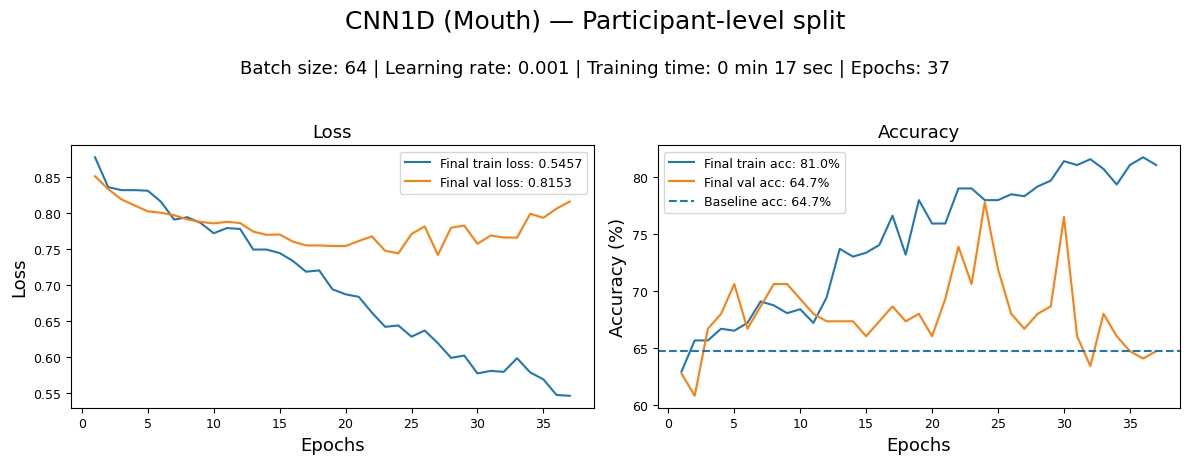

In [ ]:
Epochs = 50 
lr = 1e-3
patience=10 

model = CNN1D(len(SIGNAL_ORDER))


t0 = time.time()
model, trL, vaL, trA, vaA, trP, valP, _= train_model_with_loaders(
    model,
    train_loader,
    val_loader,
    epochs=Epochs,
    lr=lr,
    patience=patience,
    use_pos_weight=True
)
t1 = time.time()


print("Final train acc:", trA[-1])
print("Final val acc:", vaA[-1])

training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trA,
    val_accs=vaA,
    batch_size=64,
    learning_rate=0.001,
    training_time=(t1 - t0),
    baseline_acc=baseline_acc
)

## The evalutaion section

In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score

def eval_loader_binary(model, loader, device=None, threshold=0.5, verbose=True, name="LOADER"):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    y_prob_list, y_true_list, y_pred_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            logits = model(xb).view(-1)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= threshold).astype(int)

            y_prob_list.append(probs)
            y_pred_list.append(preds)
            y_true_list.append(yb.detach().cpu().numpy().astype(int).reshape(-1))

    y_true = np.concatenate(y_true_list) if y_true_list else np.array([], dtype=int)
    y_pred = np.concatenate(y_pred_list) if y_pred_list else np.array([], dtype=int)
    y_prob = np.concatenate(y_prob_list) if y_prob_list else np.array([], dtype=float)

    acc = accuracy_score(y_true, y_pred) if len(y_true) else float("nan")

    if verbose:
        print(f"{name} accuracy (window-level): {acc:.4f}")

    return y_true, y_pred, y_prob, acc


In [ ]:
print(eval_loader_binary)


<function eval_loader_binary at 0x0000027908AE1CF0>


In [ ]:
y_tr, yhat_tr, p_tr, acc_tr = eval_loader_binary(model, train_loader, name="TRAIN")
y_va, yhat_va, p_va, acc_va = eval_loader_binary(model, val_loader,   name="VAL")
y_te, yhat_te, p_te, acc_te = eval_loader_binary(model, test_loader,  name="TEST")


TRAIN accuracy (window-level): 0.8171
VAL accuracy (window-level): 0.6667
TEST accuracy (window-level): 0.7249


In [ ]:
# for the test


print(f"Accuracy:           {accuracy_score(y_te, yhat_te):.4f}")
print(f"Balanced acc:       {balanced_accuracy_score(y_te, yhat_te):.4f}")
print(f"F1 (positive):      {f1_score(y_te, yhat_te):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_te, p_te):.4f}")
print(f"Average Precision:  {average_precision_score(y_te, p_te):.4f}")

print("\nCM:\n", confusion_matrix(y_te, yhat_te))
print(classification_report(y_te, yhat_te, digits=4))


Accuracy:           0.7249
Balanced acc:       0.7083
F1 (positive):      0.6389
ROC AUC:            0.7098
Average Precision:  0.7071

CM:
 [[91 26]
 [26 46]]
              precision    recall  f1-score   support

           0     0.7778    0.7778    0.7778       117
           1     0.6389    0.6389    0.6389        72

    accuracy                         0.7249       189
   macro avg     0.7083    0.7083    0.7083       189
weighted avg     0.7249    0.7249    0.7249       189



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Put your data in a list of tuples
datasets = [
    ("TRAIN", y_tr,  yhat_tr,  p_tr),
    ("VAL",   y_va,  yhat_va,  p_va),
    ("TEST",  y_te,  yhat_te,  p_te),
]

for name, y_true, y_pred, y_prob in datasets:
    print(f"\n ----- {name}----")
    
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
    auc     = roc_auc_score(y_true, y_prob)
    ap      = average_precision_score(y_true, y_prob)
    
    print(f"Accuracy:              {acc:.4f}")
    print(f"Balanced accuracy:     {bal_acc:.4f}")
    print(f"F1 (positive class):   {f1:.4f}")
    print(f"ROC AUC:               {auc:.4f}")
    print(f"Average Precision:     {ap:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    print("━" * 50)

In [ ]:


# print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
# print(f"Balanced acc:       {balanced_accuracy_score(y_true, y_pred):.4f}")
# print(f"F1 (positive):      {f1_score(y_true, y_pred):.4f}")
# print(f"ROC AUC:            {roc_auc_score(y_true, y_prop):.4f}")
# print(f"Average Precision:  {average_precision_score(y_true, y_prop):.4f}")
# print("\nCM:\n", confusion_matrix(y_true, y_pred))
# print(classification_report(y_true, y_pred, digits=4))

In [ ]:


FULL_SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

signal_sets = [
    ["ECG_mV"],
    ["Fingerpulse"],
    ["Cannula"],                          # 1 signal
    ["Thermopod"],                        # 1 signal
    #["Cannula", "Thermopod"],             # 2 signals
    ["ECG_mV", "Fingerpulse"],            # 2 signals
    ["ECG_mV", "Cannula"],            # 2 signals
    ["ECG_mV", "Thermopod"],            # 2 signals
    ["ECG_mV", "Fingerpulse","Thermopod"],   # 3 signals
    ["ECG_mV", "Fingerpulse", "Cannula"],   # 3 signals
    FULL_SIGNAL_ORDER,                    # 4 signals
]

seeds = [1, 2, 3, 4, 5]


In [1]:
results = []
for keep in signal_sets:
    for seed in seeds:
        m = run_one_experiment(
            X_full=X_mouth,
            y=y_mouth,
            full_order=FULL_SIGNAL_ORDER,
            keep_signals=keep,
            seed=seed,
            Epochs=50,
            lr=1e-3,
            patience=10,
            batch_size=64,
        )
        print(f"done: seed={seed}, signals={keep} -> acc={m['test_acc']:.3f}, auc={m['test_roc_auc']:.3f}")
        results.append(m)


NameError: name 'signal_sets' is not defined